In [ ]:
from datetime import datetime
import os
import pickle
import numpy as np
import pandas as pd

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from generation.utils import plot_iv_surface, repair_edges_local_directional, jitter_grid
from generation.surface_generation import generate_surfaces, SimulationConfig
from models.framework import DeepONet, MLP

# ============================================================
# 1️⃣ Generate synthetic Rough Bergomi IV surfaces
# ============================================================

# cfg = SimulationConfig(M=50000, n=500, T_max=2.0, S0=1.0, G=1)
# surfaces = generate_surfaces(
#     num_sets=1,
#     forward_curves_per_set=10,
#     cfg=cfg,
#     seed=4235,
#     randomize_grid=False,
# )


SAVE_ROOT = "data/fixed_longrun"
surfaces = []

# List and sort all batch files (batch_0000.pkl, batch_0001.pkl, ...)
batch_files = sorted([
    f for f in os.listdir(SAVE_ROOT)
    if f.startswith("fixed_batch_") and f.endswith(".pkl")
])

# print(f"Found {len(batch_files)} batch files.")

for fname in batch_files:
    path = os.path.join(SAVE_ROOT, fname)
    try:
        with open(path, "rb") as f:
            data = pickle.load(f)
            # If each file stores {"surfaces": [...]} dicts:
            if isinstance(data, dict) and "surfaces" in data:
                surfaces.extend(data["surfaces"])
            # Or if it’s already a list:
            elif isinstance(data, list):
                surfaces.extend(data)
            else:
                print(f"⚠️ Unrecognized format in {fname}")
        print(f"Loaded {fname}")
    except Exception as e:
        print(f"❌ Error loading {fname}: {e}")

print(f"\n✅ Total surfaces loaded: {len(surfaces)}")

for i in surfaces:
    x = i["iv_surface"]
    maturities = np.array(i["grid"]["maturities"])
    strikes = np.array(i["grid"]["strikes"])
    i["iv_surface"] =  repair_edges_local_directional(x, maturities, strikes)

Loaded fixed_batch_0000.pkl
Loaded fixed_batch_0001.pkl
Loaded fixed_batch_0002.pkl
Loaded fixed_batch_0003.pkl
Loaded fixed_batch_0004.pkl
Loaded fixed_batch_0005.pkl
Loaded fixed_batch_0006.pkl
Loaded fixed_batch_0007.pkl
Loaded fixed_batch_0008.pkl
Loaded fixed_batch_0009.pkl
Loaded fixed_batch_0010.pkl
Loaded fixed_batch_0011.pkl
Loaded fixed_batch_0012.pkl
Loaded fixed_batch_0013.pkl
Loaded fixed_batch_0014.pkl
Loaded fixed_batch_0015.pkl
Loaded fixed_batch_0016.pkl
Loaded fixed_batch_0017.pkl
Loaded fixed_batch_0018.pkl
Loaded fixed_batch_0019.pkl
Loaded fixed_batch_0020.pkl
Loaded fixed_batch_0021.pkl
Loaded fixed_batch_0022.pkl
Loaded fixed_batch_0023.pkl
Loaded fixed_batch_0024.pkl
Loaded fixed_batch_0025.pkl
Loaded fixed_batch_0026.pkl
Loaded fixed_batch_0027.pkl
Loaded fixed_batch_0028.pkl
Loaded fixed_batch_0029.pkl
Loaded fixed_batch_0030.pkl
Loaded fixed_batch_0031.pkl
Loaded fixed_batch_0032.pkl
Loaded fixed_batch_0033.pkl
Loaded fixed_batch_0034.pkl
Loaded fixed_batch_0

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gzip
import matplotlib.ticker as mtick
import time
f = gzip.GzipFile('TrainrBergomiTermStructure.txt.gz', "r")
dat=np.load(f)
print(dat.shape)
xx=dat[:,:11]
yy=dat[:,11:]
print(xx.shape)
strikes=np.array([0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5 ])
maturities=np.array([0.1,0.3,0.6,0.9,1.2,1.5,1.8,2.0 ])
import numpy as np

# Constants from your setup
strikes = np.array([0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5])
maturities = np.array([0.1,0.3,0.6,0.9,1.2,1.5,1.8,2.0])

num_strikes = len(strikes)
num_maturities = len(maturities)
num_samples = len(xx)

surfaces = []

for i in range(num_samples):
    # forward vols (first 8), eta, rho, H
    fwd_vols = xx[i, :8].tolist()
    eta = float(xx[i, 8])
    rho = float(xx[i, 9])
    H   = float(xx[i, 10])

    # reshape yy row into surface (maturities × strikes)
    iv_surface = yy[i].reshape(num_maturities, num_strikes)

    # build the structured dictionary
    surfaces.append({
        "set_id": int(i),
        "fwd_id": int(i),  # or e.g. i // 100 if multiple fwd vols share params
        "params": {
            "eta": eta,
            "rho": rho,
            "H": H,
            "xi0_knots": fwd_vols
        },
        "grid": {
            "strikes": strikes.astype(np.float32),
            "maturities": maturities.astype(np.float32)
        },
        "iv_surface": iv_surface.astype(np.float32)
    })

# optional: check example
print(surfaces[0]["params"])
print(surfaces[0]["iv_surface"].shape)


(80000, 99)
(80000, 11)
{'eta': 1.09063, 'rho': -0.477665, 'H': 0.41078, 'xi0_knots': [0.0989267, 0.13664, 0.138692, 0.137088, 0.103535, 0.0676573, 0.0546302, 0.0185069]}
(8, 11)


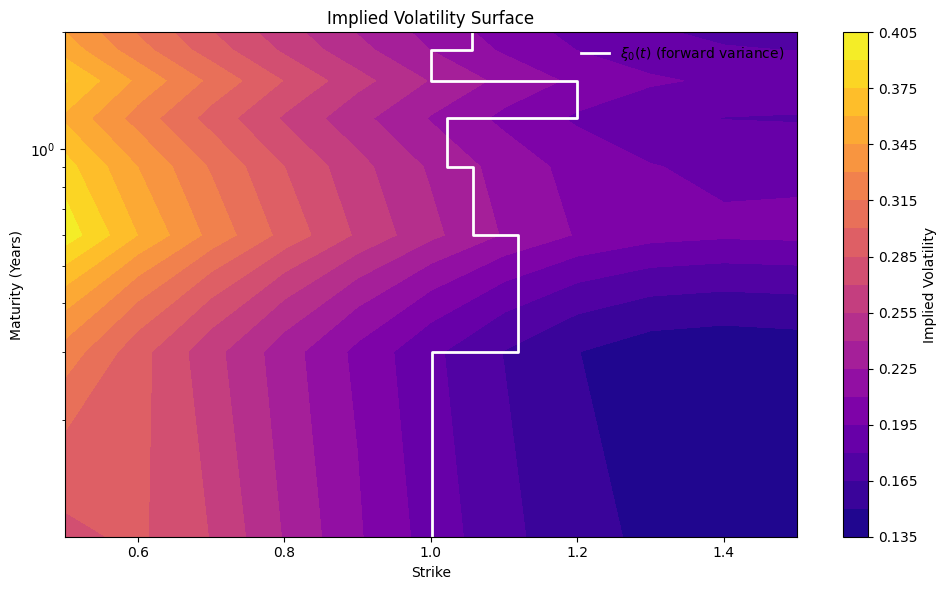

In [7]:
k = 79000
x = surfaces[k]["iv_surface"]
xi0_knots = np.array(surfaces[k]["params"]["xi0_knots"])
maturities = np.array(surfaces[k]["grid"]["maturities"])
strikes = np.array(surfaces[k]["grid"]["strikes"])
# --- reconstruct bin edges for piecewise-constant ξ₀(t) ---
# first edge starts at 0, last one ends at the final maturity
edges = np.concatenate([[0.0], maturities])
plot_iv_surface(
    x, strikes, maturities,
    xi0_knots=xi0_knots,      # K values
    xi0_bin_edges=edges,      # K+1 edges
)



Epoch 001 | train_rmse=0.193579, val_rmse=0.085144, lr=1.0e-03


Epoch 002 | train_rmse=0.074801, val_rmse=0.065540, lr=1.0e-03


Epoch 003 | train_rmse=0.063791, val_rmse=0.062814, lr=1.0e-03


Epoch 004 | train_rmse=0.058818, val_rmse=0.057061, lr=1.0e-03


Epoch 005 | train_rmse=0.052809, val_rmse=0.047965, lr=1.0e-03


...

Epoch 117 | train_rmse=0.018940, val_rmse=0.019309, lr=1.0e-05


Epoch 118 | train_rmse=0.018938, val_rmse=0.019307, lr=1.0e-05


Epoch 119 | train_rmse=0.018936, val_rmse=0.019305, lr=1.0e-05


Epoch 120 | train_rmse=0.018934, val_rmse=0.019303, lr=1.0e-05


{'pred_rel': {'mean': array([[0.54368454, 0.43102247, 0.37712878, 0.3826054 , 0.4741608 ,
          0.7414299 , 1.0166442 , 0.8912398 , 0.8635561 , 0.8928767 ,
          1.0636573 ],
         [0.45870557, 0.3976271 , 0.36132747, 0.3621272 , 0.4532464 ,
          0.66995335, 0.8201318 , 0.836844  , 0.82321995, 0.8586946 ,
          0.9713159 ],
         [0.46161547, 0.41904682, 0.41215414, 0.44498897, 0.54555845,
          0.74044585, 0.8548794 , 0.8666458 , 0.85604894, 0.87265426,
          0.9384931 ],
         [0.45283636, 0.41743547, 0.41131374, 0.45192447, 0.54725546,
          0.7340595 , 0.8610144 , 0.8692826 , 0.84410256, 0.8623178 ,
          0.9317303 ],
         [0.39593196, 0.36319095, 0.36488447, 0.408588  , 0.49060962,
          0.65062445, 0.74951905, 0.7917438 , 0.77923554, 0.7944762 ,
          0.85995567],
         [0.38195494, 0.3508434 , 0.3620207 , 0.40312272, 0.50502753,
          0.6446776 , 0.7644343 , 0.7788005 , 0.77010053, 0.79882175,
          0.85851496],
  

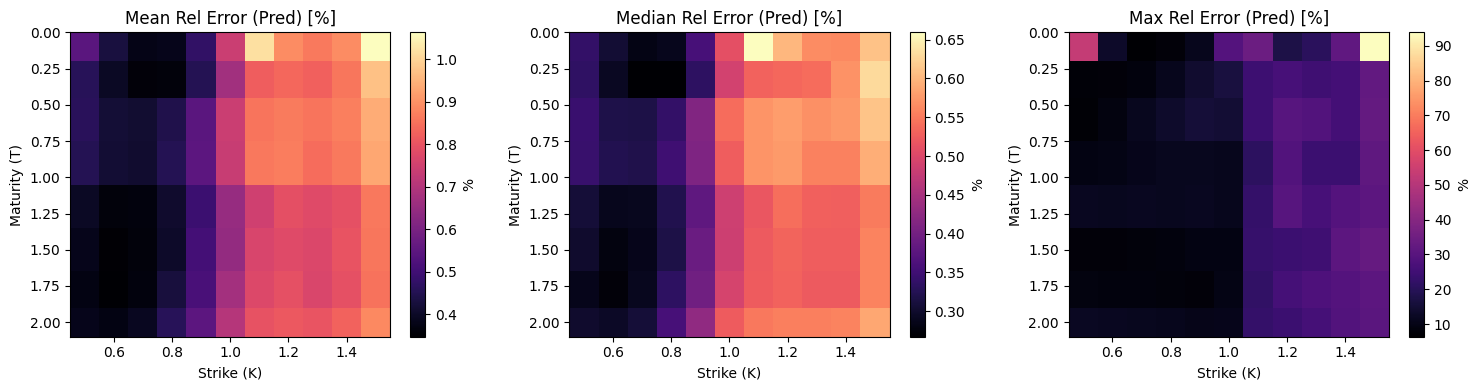

In [11]:
train_surfaces = surfaces[68000:]
test_surfaces = surfaces[:68000]

# ============================================================
# Usage Notes (example)
# ============================================================
#DeepONet (with internal scaling):
model, train_loader, val_loader, Ks, Ts = DeepONet.from_surfaces(train_surfaces,
    batch_size=88*4, val_split=0.2, eta=(0.5,4.0), rho=(0.0,1.0), H=(0.025,0.5), knot=(0.01,0.16))
model.train_model(train_loader, val_loader, epochs=120, lr_schedule=[(0,0.001),(30,0.0001), (75, 0.00001)])
# fig = model.plot_evaluation(test_surfaces[0])
model.evaluate(test_surfaces, out_dir="deeponet_eval")
#
# MLP (with internal scaling):
# model, train_loader, val_loader, Ks, Ts = MLP.from_surfaces(train_surfaces,
#     batch_size=32, val_split=0.2, hidden_dims=(64,64,64,64), eta=(0.5,4.0), rho=(0.0,1.0), H=(0.025,0.5), knot=(0.01,0.16))
# model.train_model(train_loader, val_loader, epochs=120, lr_schedule=[(0,0.001),(50,0.0001), (75, 0.00001)])
# #fig = model.plot_evaluation(test_surfaces[0])
# model.evaluate(test_surfaces, out_dir="mlp_eval")

# Consistency check 


=== Diagnostics for seed 400 ===
Simulator setup:       8.040 s
Xi0 mapping:           0.000 s
Path generation:       1.474 s
CMC integrals:         0.469 s
IV extraction total:   0.555 s (of which Brent inversions ≈   0.110 s)
TOTAL runtime:        10.538 s

=== Diagnostics for seed 400 ===
Simulator setup:       8.072 s
Xi0 mapping:           0.000 s
Path generation:       1.446 s
CMC integrals:         0.462 s
IV extraction total:   0.465 s (of which Brent inversions ≈   0.104 s)
TOTAL runtime:        10.444 s

=== Diagnostics for seed 400 ===
Simulator setup:       8.137 s
Xi0 mapping:           0.000 s
Path generation:       1.476 s
CMC integrals:         0.477 s
IV extraction total:   0.637 s (of which Brent inversions ≈   0.129 s)
TOTAL runtime:        10.728 s

=== Diagnostics for seed 400 ===
Simulator setup:       7.935 s
Xi0 mapping:           0.000 s
Path generation:       1.443 s
CMC integrals:         0.463 s
IV extraction total:   0.504 s (of which Brent inversions ≈   

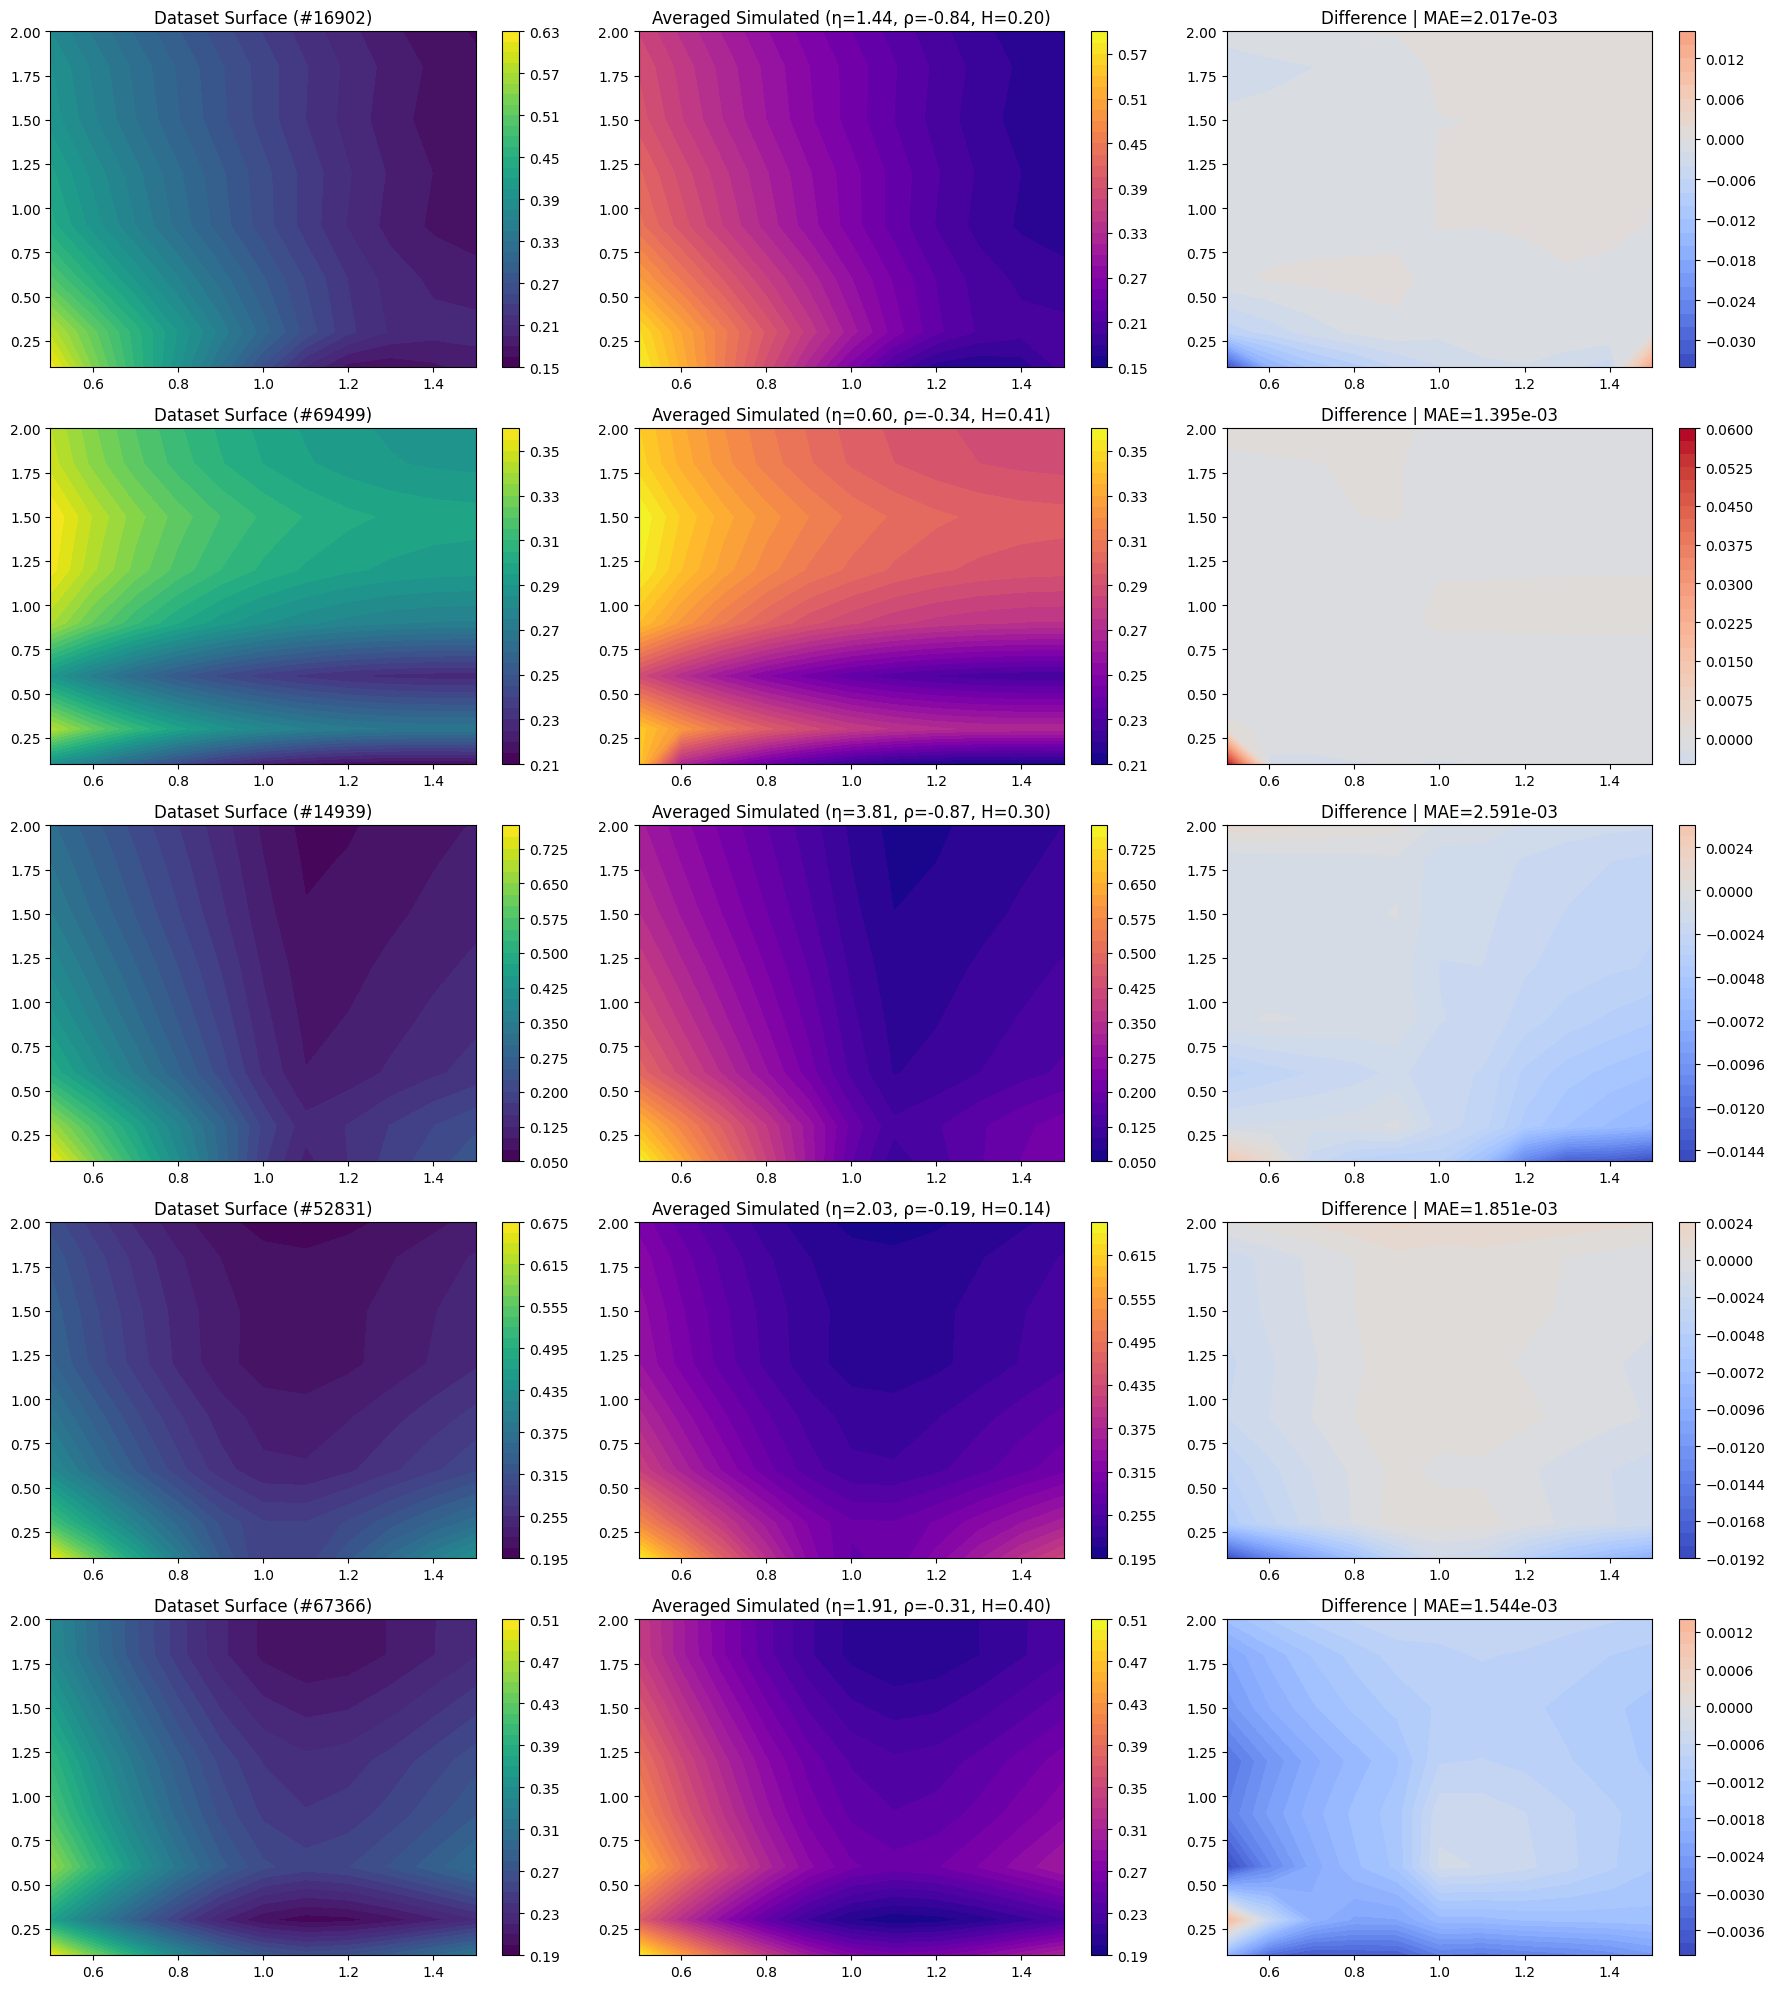

Comparison summary (averaged over seeds):
Idx 16902 | η=1.435, ρ=-0.842, H=0.201 | MAE=2.017e-03
Idx 69499 | η=0.601, ρ=-0.338, H=0.410 | MAE=1.395e-03
Idx 14939 | η=3.814, ρ=-0.875, H=0.299 | MAE=2.591e-03
Idx 52831 | η=2.031, ρ=-0.192, H=0.136 | MAE=1.851e-03
Idx 67366 | η=1.912, ρ=-0.310, H=0.403 | MAE=1.544e-03


In [1]:
import sys, os, gzip
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from generation.surface_generation import generate_fixed_surface, SimulationConfig

# ======================================================
# 1️⃣ Load data
# ======================================================

f = gzip.GzipFile("../OriginalCode/TrainrBergomiTermStructure.txt.gz", "r")
dat = np.load(f)
xx = dat[:, :11]
yy = dat[:, 11:]

strikes = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
maturities = np.array([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0])

cfg = SimulationConfig(M=50000, n=500, T_max=2.0, S0=1.0, G=1)

# ======================================================
# 2️⃣ Define subset of parameter sets to test
# ======================================================
num_tests = 5        # number of parameter combinations to test
num_seeds = 1        # how many seeds to average over
np.random.seed(123467)
test_indices = np.random.choice(len(xx), num_tests, replace=False)

# ======================================================
# 3️⃣ Run simulations and compare
# ======================================================
results = []
fig, axs = plt.subplots(num_tests, 3, figsize=(18, 4 * num_tests))
if num_tests == 1:
    axs = axs.reshape(1, -1)

for row, idx in enumerate(test_indices):
    xi0_knots = xx[idx, :8]
    eta, rho, H = xx[idx, 8:11]
    param_set = {"eta": float(eta), "rho": float(rho), "H": float(H)}

    # Average several random seeds
    sim_surfaces = []
    for s in range(num_seeds):
        seed_val = 400 + s * 17  # any deterministic spacing
        surf = generate_fixed_surface(param_set, xi0_knots, strikes, maturities, cfg, seed=seed_val)
        sim_surfaces.append(surf["iv_surface"])
    sim_surface = np.mean(sim_surfaces, axis=0)

    # True dataset surface
    true_surface = yy[idx].reshape(len(maturities), len(strikes))

    diff = sim_surface - true_surface
    mae = np.mean(np.abs(diff))
    results.append({"idx": idx, "eta": eta, "rho": rho, "H": H, "mae": mae})

    K, T = np.meshgrid(strikes, maturities)

    # Plot
    c0 = axs[row, 0].contourf(K, T, true_surface, levels=30, cmap="viridis")
    axs[row, 0].set_title(f"Dataset Surface (#{idx})")
    plt.colorbar(c0, ax=axs[row, 0])

    c1 = axs[row, 1].contourf(K, T, sim_surface, levels=30, cmap="plasma")
    axs[row, 1].set_title(f"Averaged Simulated (η={eta:.2f}, ρ={rho:.2f}, H={H:.2f})")
    plt.colorbar(c1, ax=axs[row, 1])

    vmax = np.max(np.abs(diff))
    c2 = axs[row, 2].contourf(K, T, diff, levels=30, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    axs[row, 2].set_title(f"Difference | MAE={mae:.3e}")
    plt.colorbar(c2, ax=axs[row, 2])

plt.tight_layout()
plt.show()

# ======================================================
# 4️⃣ Print summary stats
# ======================================================
print("Comparison summary (averaged over seeds):")
for r in results:
    print(f"Idx {r['idx']:>4} | η={r['eta']:.3f}, ρ={r['rho']:.3f}, H={r['H']:.3f} | MAE={r['mae']:.3e}")


# MC Noise estimation

In [10]:
def plot_simulation_noise_heatmap(param_set, xi0_knots, strikes, maturities, cfg,
                                  num_repeats=5, seed_base=1000, figsize=(6,5), levels=30):
    """
    Re-simulates the same parameter world multiple times and visualizes the
    pointwise absolute difference (Monte Carlo noise) as a heatmap.

    Each cell (T,K) shows the mean absolute deviation of IV across repeated MC runs.
    """
    # --- Generate surfaces for identical parameters ---
    surfaces = []
    for i in range(num_repeats):
        seed_val = seed_base + 37 * i
        surf = generate_fixed_surface(param_set, xi0_knots, strikes, maturities, cfg, seed=seed_val)
        surfaces.append(surf["iv_surface"])
    surfaces = np.stack(surfaces, axis=0)  # (num_repeats, nT, nK)

    # --- Compute pairwise absolute differences ---
    nR = num_repeats
    abs_diffs = np.zeros_like(surfaces[0])
    count = 0
    for i in range(nR):
        for j in range(i+1, nR):
            abs_diffs += np.abs(surfaces[i] - surfaces[j])
            count += 1
    abs_diffs /= count

    # --- Plot ---
    K, T = np.meshgrid(strikes, maturities)
    fig, ax = plt.subplots(figsize=figsize)
    c = ax.contourf(K, T, abs_diffs, levels=levels, cmap="inferno")
    plt.colorbar(c, ax=ax, label="Mean |ΔIV| across MC runs")
    ax.set_title(f"Monte Carlo Noise Heatmap ({num_repeats} runs)")
    ax.set_xlabel("Strike")
    ax.set_ylabel("Maturity")

    # Print global stats
    mean_mae = np.mean(abs_diffs)
    print(f"Global noise floor (mean abs diff): {mean_mae:.4e}")

    return fig, abs_diffs



Global noise floor (mean abs diff): 2.3603e-03


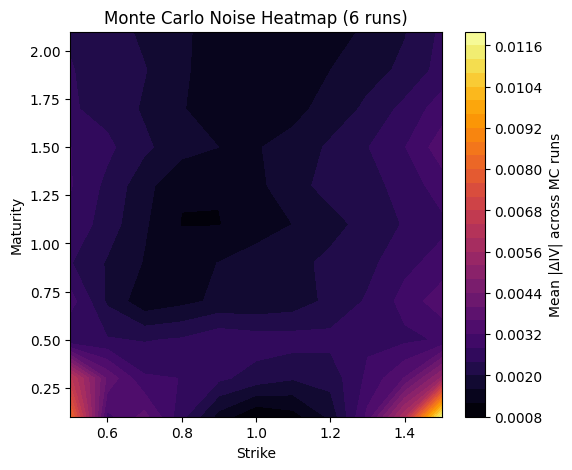

In [14]:
from generation.surface_generation import generate_fixed_surface
import matplotlib.pyplot as plt
# Define fixed grid
strikes = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
maturities = np.array([0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 1.9, 2.1])

# Example parameter set
param_set = {"eta": 2.5, "rho": -0.6, "H": 0.05}

# Choose same number of xi₀ knots as maturities
rng = np.random.default_rng(42)
xi0_knots = rng.uniform(0.01, 0.16, size=len(maturities))

# Plot Monte-Carlo noise heatmap
fig, noise_map = plot_simulation_noise_heatmap(
    param_set=param_set,
    xi0_knots=xi0_knots,
    strikes=strikes,
    maturities=maturities,
    cfg=cfg,               # your SimulationConfig
    num_repeats=6,
    seed_base=1234
)
plt.show()
